# Ejemplo de entrenamiento de CNNs

Este ejemplo es una modificación del ejemplo implementado en Kaggle por Gabriel Preda en https://www.kaggle.com/code/gpreda/cnn-with-tensorflow-keras-for-fashion-mnist. El ejemplo está construido con el dataset Fashion-MNIST que contiene imágenes de artículos de vestir en escala de grises, de 28x28 pixels. El dataset contiene 10 clases diferentes: 

0: T-shirt/top   
1: Trouser   
2: Pullover   
3: Dress   
4: Coat   
5: Sandal   
6: Shirt   
7: Sneaker   
8: Bag   
9: Ankle boot.

Esta versión del ejemplo ha sido elaborado para el curso de Inteligencia Artificial del programa de Ingeniería de Sistemas de la Universidad del Magdalena.

In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
import plotly.graph_objs as go
import plotly.figure_factory as ff
from plotly import tools
from plotly.subplots import make_subplots
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
#init_notebook_mode(connected=True)

## Inspección del dataset

El dataset fue descargado de Kaggle en archivos de formato .csv y guardados en el directoría de trabajo.

In [21]:
PATH = './fashion_mnist/'

train_file = PATH+"fashion-mnist_train.csv"
test_file  = PATH+"fashion-mnist_test.csv"

train_data = pd.read_csv(train_file)
test_data = pd.read_csv(test_file)

IMG_ROWS = 28
IMG_COLS = 28

In [17]:
print('Contenido del archivo para entrenamiento:\n')
print(train_data.info())
print('\nContenido del archivo para prueba:\n')
print(test_data.info())

Contenido del archivo para entrenamiento:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB
None

Contenido del archivo para prueba:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 59.9 MB
None


El data frame cuenta con 60000 ejemplos para entrenamiento y 10000 ejemplos para prueba. Cada ejemplo está aplanado en forma de vector con 784 pixeles. La clase está contenida en una columna del dataframe llamada label, la cuál contiene valores enteros de 0-9 para identificar las diferentes prendas de vestir.  

In [18]:
print('Resultado de la función describe para observar los valores de intensidad de las imágenes y valor que toma la variable a predecir label \n')
print(train_data.describe())

Resultado de la función describe para observar los valores de intensidad de las imágenes y valor que toma la variable a predecir label 

              label        pixel1        pixel2        pixel3        pixel4  \
count  60000.000000  60000.000000  60000.000000  60000.000000  60000.000000   
mean       4.500000      0.000900      0.006150      0.035333      0.101933   
std        2.872305      0.094689      0.271011      1.222324      2.452871   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        2.000000      0.000000      0.000000      0.000000      0.000000   
50%        4.500000      0.000000      0.000000      0.000000      0.000000   
75%        7.000000      0.000000      0.000000      0.000000      0.000000   
max        9.000000     16.000000     36.000000    226.000000    164.000000   

             pixel5        pixel6        pixel7        pixel8        pixel9  \
count  60000.000000  60000.000000  60000.000000  60000.000000  60000.000

## Parameters

['fashion-mnist_test.csv', 'fashion-mnist_train.csv', 't10k-images-idx3-ubyte', 't10k-images-idx3-ubyte.zip', 't10k-labels-idx1-ubyte', 'train-images-idx3-ubyte', 'train-images-idx3-ubyte.zip', 'train-labels-idx1-ubyte']


# Distribución de las categorías en el dataset.

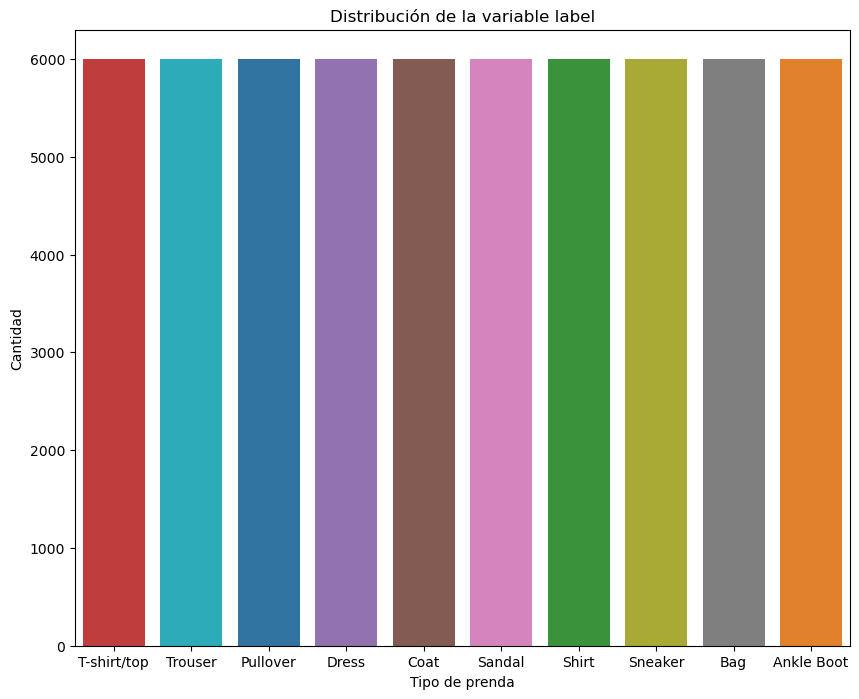

In [14]:
# Create a dictionary for each type of label 
labels = {0 : "T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
          5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot"}

train_data["clothing_type"] = train_data["label"].map(labels)

ax=plt.subplots(1,1,figsize=(10,8))
sns.countplot(x="clothing_type", data=train_data, order=list(labels.values()), hue="clothing_type", palette="tab10", legend=False)
plt.xlabel("Tipo de prenda")        # Etiqueta eje X
plt.ylabel("Cantidad") 
plt.title("Distribución de la variable label")
plt.show()

El dataset está balanceado cada categoría contiene la misma cantidad de ejemplos. 

## Visualización de algunas de las imágenes del dataset por cada categoría.

In [23]:
def sample_images_data(data):
    # An empty list to collect some samples
    sample_images = []
    sample_labels = []

    # Iterate over the keys of the labels dictionary defined in the above cell
    for k in labels.keys():
        # Get four samples for each category
        samples = data[data["label"] == k].head(4)
        # Append the samples to the samples list
        for j, s in enumerate(samples.values):
            # First column contain labels, hence index should start from 1
            img = samples.iloc[j, 1:785].values
            img = img.astype(np.float32)
            img = img.reshape(IMG_ROWS, IMG_COLS)
            sample_images.append(img)
            sample_labels.append(samples.iloc[j, 0])

    return sample_images, sample_labels

train_sample_images, train_sample_labels = sample_images_data(train_data)

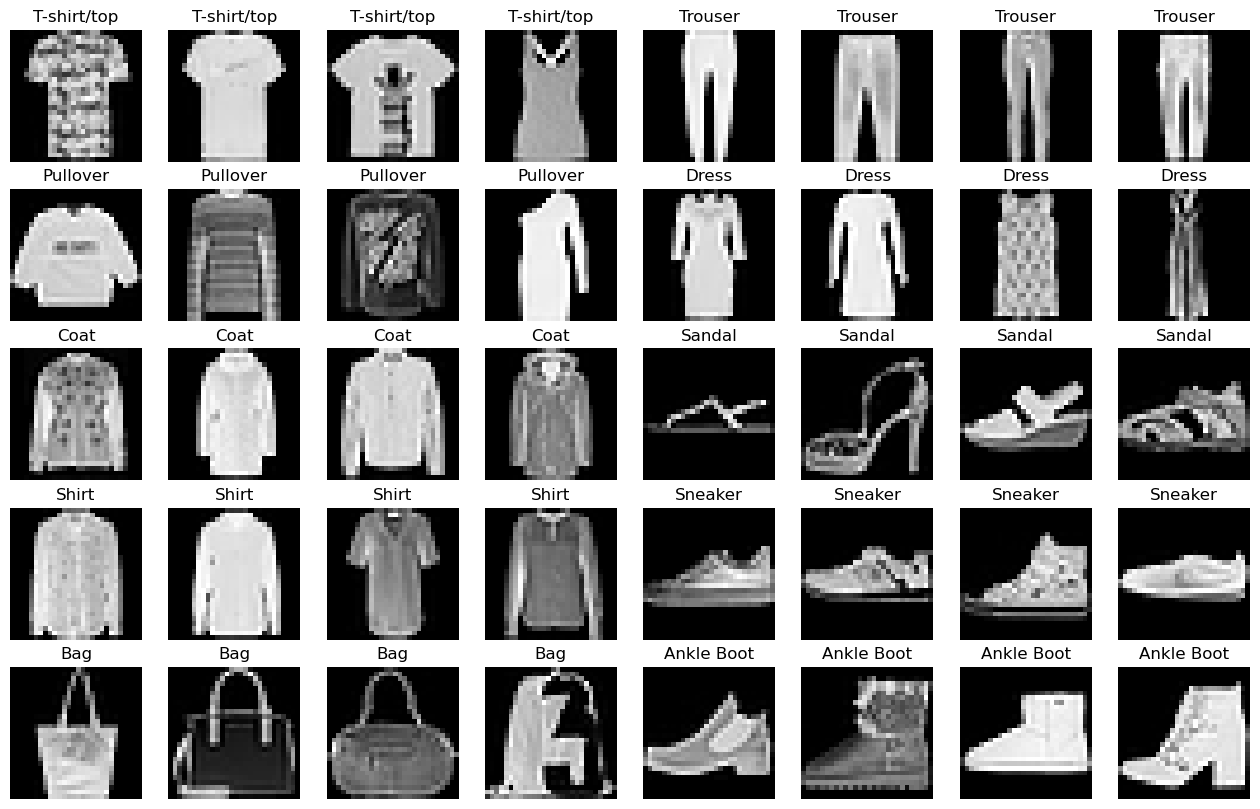

In [25]:
def plot_sample_images(data_sample_images,data_sample_labels,cmap="Blues"):
    # Plot the sample images now
    f, ax = plt.subplots(5,8, figsize=(16,10))

    for i, img in enumerate(data_sample_images):
        ax[i//8, i%8].imshow(img, cmap=cmap)
        ax[i//8, i%8].axis('off')
        ax[i//8, i%8].set_title(labels[data_sample_labels[i]])
    plt.show()    
    
plot_sample_images(train_sample_images,train_sample_labels, "gray")

## Ejemplos de histogramas de las imágenes uno por cada categoría.

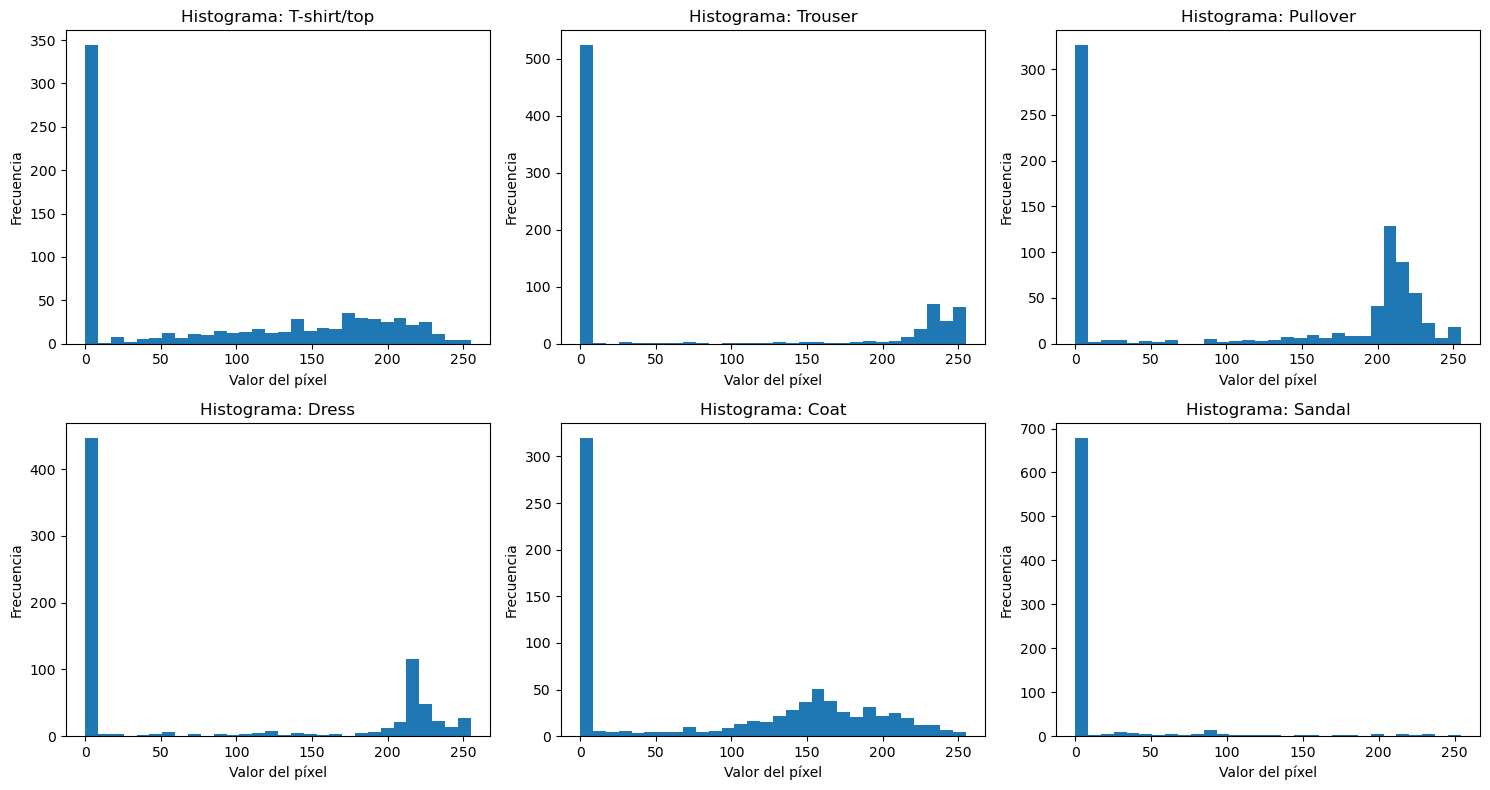

In [26]:
indices = [0, 4, 8, 12, 16, 20]

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

for i, idx in enumerate(indices):
    img = train_sample_images[idx]
    label_name = labels[train_sample_labels[idx]]

    ax[i//3, i%3].hist(img.ravel(), bins=30)
    ax[i//3, i%3].set_title(f"Histograma: {label_name}")
    ax[i//3, i%3].set_xlabel("Valor del píxel")
    ax[i//3, i%3].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## Implementación de los modelos

In [59]:
import os
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, Dropout, MaxPooling2D
from tensorflow.keras.utils import to_categorical, plot_model, model_to_dot

from sklearn.metrics import confusion_matrix

NUM_CLASSES = 10
TEST_SIZE = 0.2
RANDOM_STATE = 2018
NO_EPOCHS = 50
BATCH_SIZE = 128

Funciones para mostrar resultados:

In [63]:
def print_confusion_matrix(predicciones, true_classes):
    predicted_classes = np.argmax(predicciones, axis=1)
    y_true = np.argmax(true_classes, axis=1)
    confusion_mat = confusion_matrix(y_true, predicted_classes)

    plt.figure(figsize=(8, 6)) # Tamaño de la figura
    sns.set(font_scale=1.2) # Escala de la fuente
    sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=target_names, # Nombres de clase en x
            yticklabels=target_names, # Nombres de clase en y
            square=True, # Celdas cuadradas
            linewidths=0.5, # Espacio entre celdas
            linecolor='white', # Color de línea entre celdas
            annot_kws={"size": 14}) # Tamaño del texto interno

    plt.xlabel('Predicción', fontsize=14, fontweight='bold')
    plt.ylabel('Real', fontsize=14, fontweight='bold')
    plt.title('Matriz de Confusión - Modelo CNN', fontsize=16, fontweight='bold')
    plt.show()

def print_metric_report(predicciones, true_classes):
    predicted_classes = np.argmax(predicciones, axis=1)
    y_true = np.argmax(true_classes, axis=1)
    target_names = ["Class {} ({}) :".format(i,labels[i]) for i in range(NUM_CLASSES)]
    print(classification_report(y_true, predicted_classes, target_names=target_names))    

In [68]:
def create_trace(x,y,ylabel,color):
        trace = go.Scatter(
            x = x,y = y,
            name=ylabel,
            marker=dict(color=color),
            mode = "markers+lines",
            text=x
        )
        return trace
    
def plot_accuracy_and_loss(train_model):
    hist = train_model.history
    acc = hist['accuracy']
    val_acc = hist['val_accuracy']
    loss = hist['loss']
    val_loss = hist['val_loss']
    epochs = list(range(1,len(acc)+1))
    
    trace_ta = create_trace(epochs,acc,"Training accuracy", "Green")
    trace_va = create_trace(epochs,val_acc,"Validation accuracy", "Red")
    trace_tl = create_trace(epochs,loss,"Training loss", "Blue")
    trace_vl = create_trace(epochs,val_loss,"Validation loss", "Magenta")
   
    fig = fig = make_subplots(rows=1, cols=2, subplot_titles=('Training and validation accuracy', 'Training and validation loss'))
    fig.append_trace(trace_ta,1,1)
    fig.append_trace(trace_va,1,1)
    fig.append_trace(trace_tl,1,2)
    fig.append_trace(trace_vl,1,2)
    fig['layout']['xaxis'].update(title = 'Epoch')
    fig['layout']['xaxis2'].update(title = 'Epoch')
    fig['layout']['yaxis'].update(title = 'Accuracy', range=[0,1])
    fig['layout']['yaxis2'].update(title = 'Loss', range=[0,1])
    
    iplot(fig, filename='accuracy-loss')

### Preparación de los datos

En este ejemplo se implementan modelos de redes neuronales convolutivas (CNN) que reciben las imágenes completas representadas como arreglos de dos y tres dimensiones. Entonces de debe hacer un reshape de las imágenes de vectores de 784 posiciones a arreglos de 28x28x1.

In [28]:
def data_preprocessing(raw):
    out_y = tf.keras.utils.to_categorical(raw["label"], num_classes=NUM_CLASSES)
    num_images = raw.shape[0]
    x_as_array = raw.iloc[:, 1:785].values
    x_as_array = x_as_array.astype(np.float32)
    x_shaped_array = x_as_array.reshape(num_images, IMG_ROWS, IMG_COLS, 1)
    out_x = x_shaped_array / 255.0
    return out_x, out_y

In [33]:
X, y = data_preprocessing(train_data)
X_test, y_test = data_preprocessing(test_data)

#### Data set de validación
Se extrae un conjunto de datos para validación del conjunto de entrenamiento. Estos es para que los métodos de entrenamiento de lo utilice para estimar desempeños parciales de los modelos a medidas que se lleva a cabo el proceso, sin utilizar los datos de prueba.

In [34]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

Luego de esta instrucción los datos para entrenamiento, validación y prueba quedan distribuidos de la siguiente manera:

In [35]:
print("Fashion MNIST train -  rows:",X_train.shape[0]," columns:", X_train.shape[1:4])
print("Fashion MNIST valid -  rows:",X_val.shape[0]," columns:", X_val.shape[1:4])
print("Fashion MNIST test  -  rows:",X_test.shape[0]," columns:", X_test.shape[1:4])

Fashion MNIST train -  rows: 48000  columns: (28, 28, 1)
Fashion MNIST valid -  rows: 12000  columns: (28, 28, 1)
Fashion MNIST test  -  rows: 10000  columns: (28, 28, 1)


## Primer Modelo CNN
Un modelo construido por capas con una capa de entrada del mismo tamaño de las imágenes. Tres capas de convolución de diferentes tamaños 32, 64 y 128, con kernels de 3x3, intercaladas con operaciones de MaxPooling, y termina en una capa plana, complentamente conectada a una capa más de 128 nueuronas, y finaliza con una capa de salida con un número de neuronas igual al número de clases del problema. 

In [36]:
# Model
model = Sequential()

model.add(Input(shape=(IMG_ROWS, IMG_COLS, 1)))

# Add convolution 2D
model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 kernel_initializer='he_normal'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, 
                 kernel_size=(3, 3), 
                 activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(NUM_CLASSES, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer='adam',
              metrics=['accuracy'])

Debajo se puede observar resumidamente la constitución del modelo y el número de parámetros (pesos del modelo) cuyos valores deben ser encontrados durante el proceso de entrenamiento.

In [37]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

La siguiente función realiza todo el proceso de entrenamiento, a la cual se le envían algunos hiperparámetros importantes como el tamaño del lote, el número máximo de iteraciones, y los datasets de entrenamiento y validación. 

In [38]:
train_model = model.fit(X_train, y_train,
                  batch_size=BATCH_SIZE,
                  epochs=NO_EPOCHS,
                  verbose=1,
                  validation_data=(X_val, y_val))

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8066 - loss: 0.5296 - val_accuracy: 0.8587 - val_loss: 0.3921
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8766 - loss: 0.3410 - val_accuracy: 0.8838 - val_loss: 0.3195
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8934 - loss: 0.2919 - val_accuracy: 0.8785 - val_loss: 0.3273
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9044 - loss: 0.2573 - val_accuracy: 0.8945 - val_loss: 0.2971
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9152 - loss: 0.2306 - val_accuracy: 0.9033 - val_loss: 0.2727
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9213 - loss: 0.2089 - val_accuracy: 0.9044 - val_loss: 0.2733
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9306 - loss: 0.1868 - val_accuracy: 0.9080 - val_loss: 0.2614
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9379 - loss: 0.1658 - val_accu

Como se puede observar al entrenar el modelo la función fit nos muestra progresivamente el desempeño del modelo tanto en el dataset de entrenamiento como en el de validadicón.

Miremos gráficamente el progreso del modelo durante el entrenamiento.

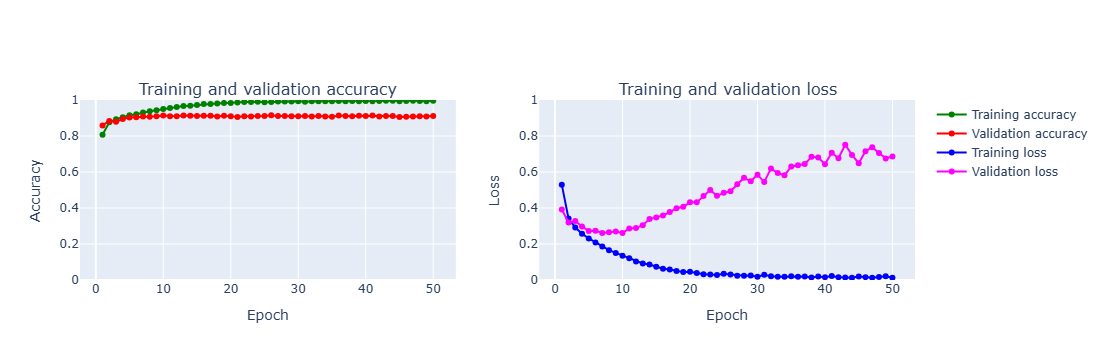

In [69]:
plot_accuracy_and_loss(train_model)

El progreso del desempeño del modelo sobre el conjunto de datos de validación muestra que hubo un estancamiento en el accuracy desde la primeras iteraciones y un desmejoramiento en la función de perdida. 

#### Prueba

In [75]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.6529954671859741
Test accuracy: 0.9106000065803528


El resultado de la evaluación del modelo sobre los datos de prueba nos muestra un accuracy del 91%. Veamos la matriz de confusión y algunas métricas de desempeño de este modelo.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step 


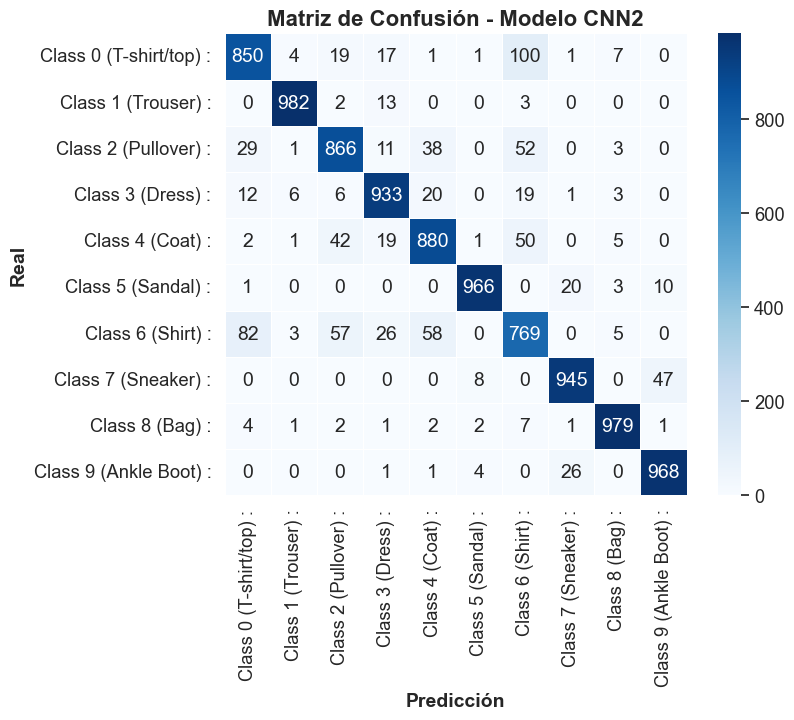

In [73]:
predicted1 = model.predict(X_test)
print_confusion_matrix(predicted, y_test)

In [74]:
print_metric_report(predicted1, y_test)

                         precision    recall  f1-score   support

Class 0 (T-shirt/top) :       0.87      0.85      0.86      1000
    Class 1 (Trouser) :       0.98      0.98      0.98      1000
   Class 2 (Pullover) :       0.87      0.87      0.87      1000
      Class 3 (Dress) :       0.91      0.93      0.92      1000
       Class 4 (Coat) :       0.88      0.88      0.88      1000
     Class 5 (Sandal) :       0.98      0.97      0.97      1000
      Class 6 (Shirt) :       0.77      0.77      0.77      1000
    Class 7 (Sneaker) :       0.95      0.94      0.95      1000
        Class 8 (Bag) :       0.97      0.98      0.98      1000
 Class 9 (Ankle Boot) :       0.94      0.97      0.96      1000

               accuracy                           0.91     10000
              macro avg       0.91      0.91      0.91     10000
           weighted avg       0.91      0.91      0.91     10000



Las prendas de vestir que mejor clasifica el modelo son: Class 1 (Trouser), Class 5 (Sandal), Class 8 (Bag), y la que menos clasifica correctamente es: Class 6 (Shirt).

## Segundo Modelo CNN

El mismo modelo con capas de Dropout.

In [76]:
# Model
model = Sequential()
# Add convolution 2D
model.add(Input(shape=(IMG_ROWS, IMG_COLS, 1)))
model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 kernel_initializer='he_normal'))
model.add(MaxPooling2D((2, 2)))
# Add dropouts to the model
model.add(Dropout(0.25))
model.add(Conv2D(64, 
                 kernel_size=(3, 3), 
                 activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
# Add dropouts to the model
model.add(Dropout(0.25))
model.add(Conv2D(128, (3, 3), activation='relu'))
# Add dropouts to the model
model.add(Dropout(0.4))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
# Add dropouts to the model
model.add(Dropout(0.3))
model.add(Dense(NUM_CLASSES, activation='softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer='adam',
              metrics=['accuracy'])

Resumen del modelo.

In [84]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento:

In [77]:
train_model = model.fit(X_train, y_train,
                  batch_size=BATCH_SIZE,
                  epochs=NO_EPOCHS,
                  verbose=1,
                  validation_data=(X_val, y_val))

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7156 - loss: 0.7566 - val_accuracy: 0.8240 - val_loss: 0.4714
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8210 - loss: 0.4835 - val_accuracy: 0.8559 - val_loss: 0.3953
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8494 - loss: 0.4154 - val_accuracy: 0.8798 - val_loss: 0.3247
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8646 - loss: 0.3720 - val_accuracy: 0.8878 - val_loss: 0.3086
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8728 - loss: 0.3496 - val_accuracy: 0.8961 - val_loss: 0.2941
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8800 - loss: 0.3296 - val_accuracy: 0.8975 - val_loss: 0.2825
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8834 - loss: 0.3167 - val_accuracy: 0.9023 - val_loss: 0.2711
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8884 - loss: 0.3035 - val_accu

Progresión del accuracy y la función de perdida sobre los dataset de entrenamiento y validación, a medida que el modelo se entrenaba.

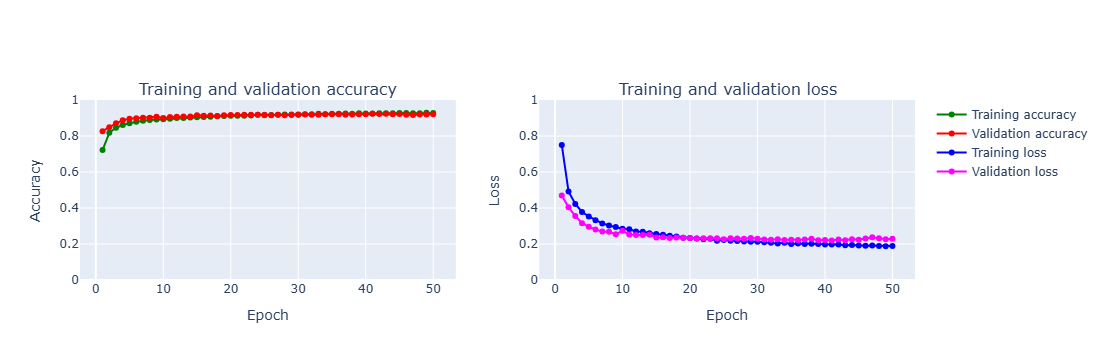

In [88]:
plot_accuracy_and_loss(train_model)

### Prueba del segundo modelo

In [78]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.20262426137924194
Test accuracy: 0.9269000291824341


In [102]:
predicted2 = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step 


Matriz de confusión:

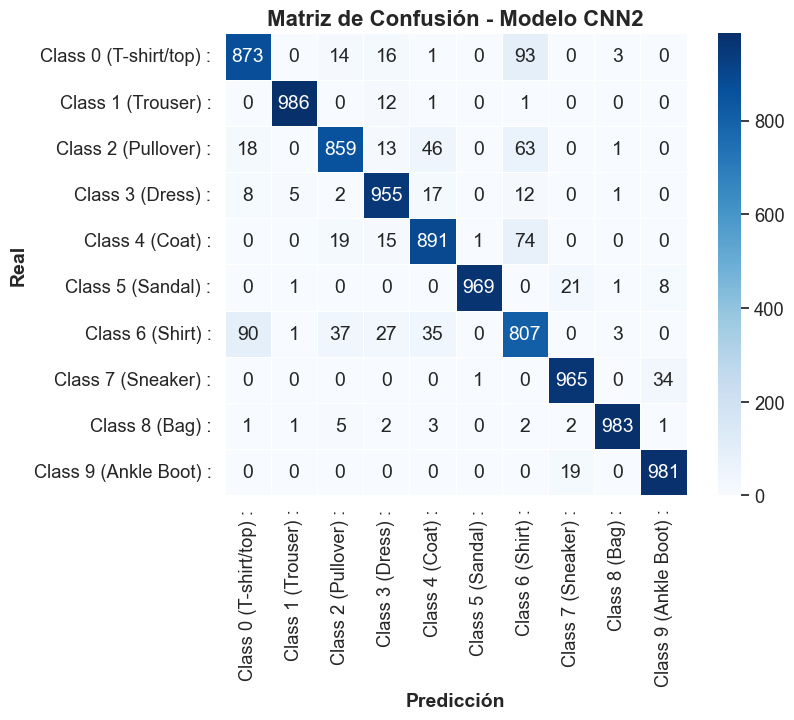

In [80]:
print_confusion_matrix(predicted2, y_test)

En este segundo experimento, la clase 6 sigue siendo la de menor desempeño en la clasificación; pero el resultado mejoró en comparación con los resultados del primer experimento. La confusión se presenta más que todo entre la clase 6 y la clase 0.

In [82]:
print_metric_report(predicted2, y_test)

                         precision    recall  f1-score   support

Class 0 (T-shirt/top) :       0.88      0.87      0.88      1000
    Class 1 (Trouser) :       0.99      0.99      0.99      1000
   Class 2 (Pullover) :       0.92      0.86      0.89      1000
      Class 3 (Dress) :       0.92      0.95      0.94      1000
       Class 4 (Coat) :       0.90      0.89      0.89      1000
     Class 5 (Sandal) :       1.00      0.97      0.98      1000
      Class 6 (Shirt) :       0.77      0.81      0.79      1000
    Class 7 (Sneaker) :       0.96      0.96      0.96      1000
        Class 8 (Bag) :       0.99      0.98      0.99      1000
 Class 9 (Ankle Boot) :       0.96      0.98      0.97      1000

               accuracy                           0.93     10000
              macro avg       0.93      0.93      0.93     10000
           weighted avg       0.93      0.93      0.93     10000



## Tercer Modelo VGG16

Esta parte es un ejemplo de TranferLearning, se importa un modelo VGG16 preentrenado en un gran dataset llamado Imagenet. En este ejemplo se fijarán los pesos ya estimados para el modelo, y se añadiran unas últimas capas al modelo que serán entrenada con el dataset que estamos utilizando. 

In [84]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers

In [86]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(48, 48, 3)
)
base_model.trainable = False

In [87]:
inputs = keras.Input(shape=(IMG_ROWS, IMG_COLS, 1))
x = layers.Resizing(48, 48)(inputs)
x = layers.Concatenate(axis=-1)([x, x, x])
x = layers.Rescaling(255.0)(x)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model_vgg16 = keras.Model(inputs=inputs, outputs=outputs)

Este modelo está constituido por por una capa de entrada, seguida de tres capas que son utilizadas para aplicar algunas operaciones de preparación de las imágenes para adaptarlas a la entrada requerida por VGG16. Estas operaciones son un resize a 48x48, convertir las imágenes a formato con tres canales, un rescaling de los valores originales de intensidad en escala de 0 a 255, y otras operaciones más que se aplican en preprocess_input especificas para el uso de VGG16. Luego, como se puede observar sigue el modelo base que es la parte reutilizada de VGG16 y a esta se le añaden las últimas capas que van a ser entrenadas para especializar el modelo en el dataset con el cual estamos trabajando. La siguiente función muestra de manera resumida la arquitectura completa.

In [88]:
model_vgg16.summary()

Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)    │ (None, 28, 28, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resizing (Resizing)           │ (None, 48, 48, 1)         │               0 │ input_layer_6[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 48, 48, 3)         │               0 │ resizing[0][0],            │
│                               │                           │                 │ resizing[0][0],            │
│                               │                           │                 │ resizing[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 48, 48, 3)         │               0 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 48, 48)            │               0 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_1 (GetItem)          │ (None, 48, 48)            │               0 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_2 (GetItem)          │ (None, 48, 48)            │               0 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stack (Stack)                 │ (None, 48, 48, 3)         │               0 │ get_item[0][0],            │
│                               │                           │                 │ get_item_1[0][0],          │
│                               │                           │                 │ get_item_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 48, 48, 3)         │               0 │ stack[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ vgg16 (Functional)            │ (None, 1, 1, 512)         │      14,714,688 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_4 (Flatten)           │ (None, 512)               │               0 │ vgg16[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_8 (Dense)               │ (None, 256)               │         131,328 │ flatten_4[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_8 (Dropout)           │ (None, 256)               │               0 │ dense_8[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_9 (Dense)               │ (None, 10)                │           2,570 │ dropout_8[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [93]:
model_vgg16.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
   )

In [94]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_vgg16 = model_vgg16.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop]
)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 190s 504ms/step - accuracy: 0.7113 - loss: 0.9610 - val_accuracy: 0.7900 - val_loss: 0.6188
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 202s 539ms/step - accuracy: 0.7108 - loss: 0.8877 - val_accuracy: 0.8033 - val_loss: 0.5923
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 205s 546ms/step - accuracy: 0.6959 - loss: 0.9201 - val_accuracy: 0.7713 - val_loss: 0.7053
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 208s 554ms/step - accuracy: 0.7065 - loss: 0.8955 - val_accuracy: 0.7878 - val_loss: 0.6820
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 208s 556ms/step - accuracy: 0.7147 - loss: 0.8819 - val_accuracy: 0.8100 - val_loss: 0.6303
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 209s 558ms/step - accuracy: 0.7122 - loss: 0.8741 - val_accuracy: 0.7962 - val_loss: 0.6742
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 208s 555ms/step - accuracy: 0.7087 - loss: 0.8744 - val_accuracy: 0.8050 - val_loss: 0.7523


Progresión del entrenamiento:

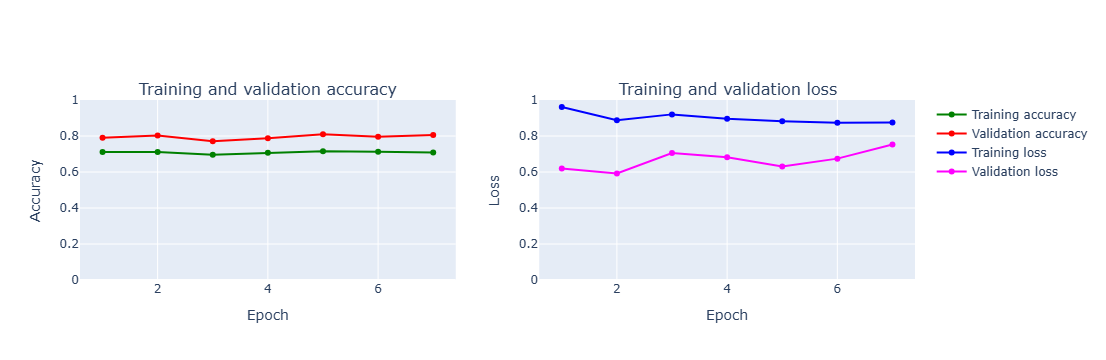

In [98]:
plot_accuracy_and_loss(history_vgg16)

En este caso especialmente la función de error muestra un modelo subajustado.

### Prueba

In [99]:
score = model_vgg16.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.608038604259491
Test accuracy: 0.8023999929428101


In [104]:
predicted3 = model_vgg16.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step


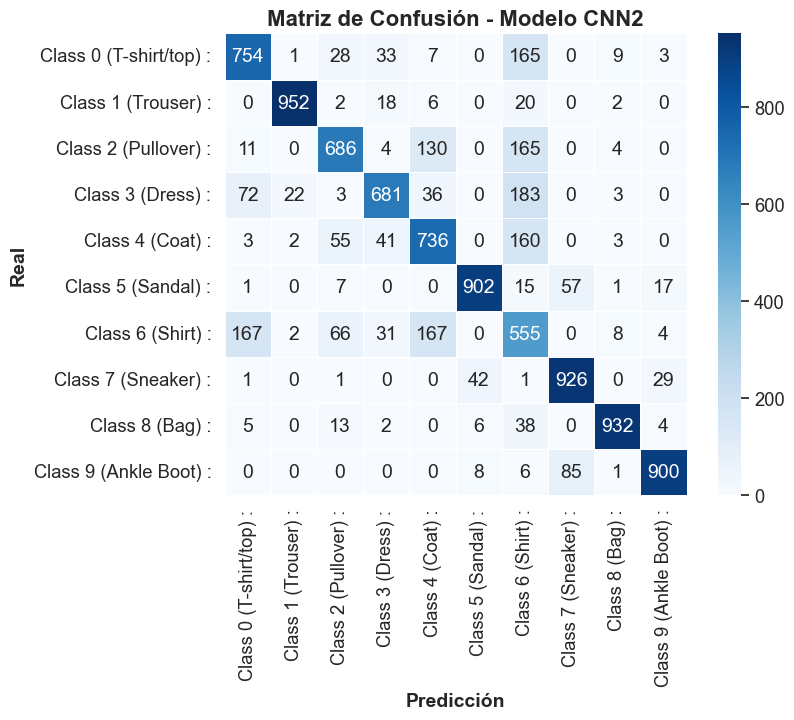

In [105]:
print_confusion_matrix(predicted3, y_test)

In [107]:
print_metric_report(predicted3, y_test)

                         precision    recall  f1-score   support

Class 0 (T-shirt/top) :       0.74      0.75      0.75      1000
    Class 1 (Trouser) :       0.97      0.95      0.96      1000
   Class 2 (Pullover) :       0.80      0.69      0.74      1000
      Class 3 (Dress) :       0.84      0.68      0.75      1000
       Class 4 (Coat) :       0.68      0.74      0.71      1000
     Class 5 (Sandal) :       0.94      0.90      0.92      1000
      Class 6 (Shirt) :       0.42      0.56      0.48      1000
    Class 7 (Sneaker) :       0.87      0.93      0.90      1000
        Class 8 (Bag) :       0.97      0.93      0.95      1000
 Class 9 (Ankle Boot) :       0.94      0.90      0.92      1000

               accuracy                           0.80     10000
              macro avg       0.82      0.80      0.81     10000
           weighted avg       0.82      0.80      0.81     10000



Hay una desmejora considerablemente alta en el desempeño del modelo para identificar las clases correctas, especialmente para la clase 6.